# TP1 PROCESAMIENTO DEL HABLA: webscrapping

**Crea una copia de este notebook en tu google colab**

**Renombra el notebook con el siguiente formato APELLIDO_NOMBRE_PH_TP1.ipynb**

**[LUCIA ALEXIA PELLEGRINI]**


* Resolver las consignas comentando el código fuente, indicando desde dónde fue extraido o generado.

* Explicar y justificar cada paso realizado usando los bloques de texto.

* Publique enlace público a su notebook en google colab y también enlace a su repositorio github de la materia.


## EJERCICIO CONSIGNA

* Cree una nube de palabras de un texto en español.

* Dicho texto puede ser descargado de Internet (webscrapping) o extraído del dataset de alguna librería.

* Puede usar cualquier libreria o herramienta para obtener el texto de su interés.

* En este notebook explica el paso a paso del proceso.



## 1- Webscrapping

Extrae un texto de Internet de una sóla página web usando alguna de las técnicas de webscrapping vistas en clase. Busca el discurso de alguna persona quien te inspire o haya dado una charla motivadora.

No puedes repetir ni usar ni el mismo texto ni la misma web que otra persona quien ya entregó en el foro.

Abajo añade los bloques de código y texto necesarios. Explica paso a paso como descargaste el texto de tu interés.


In [1]:
!pip install beautifulsoup4
!pip install requests
!pip install nltk
!pip install wordcloud
!pip install matplotlib
!pip install pandas
!pip install scikit-learn
!pip install numpy

###SCRAPING

In [13]:
import requests
from bs4 import BeautifulSoup

url = "https://www.educ.ar/recursos/108644/rene-favaloro-hay-que-sentir-al-paciente" #copio url de la web correspondiente

try:
    respuesta = requests.get(url, timeout=10) #le doy 10seg
    respuesta.raise_for_status()

    soup = BeautifulSoup(respuesta.text, "html.parser")


    titulo_tag = soup.find("h1")          #me parecio bueno extraer el título
    titulo = titulo_tag.get_text(strip=True) if titulo_tag else "Sin título"


    parrafos = soup.find_all("p")      #extraemos el texto en párrafos
    texto_parrafos = " ".join([p.get_text(strip=True) for p in parrafos])

    print("--- SCRAPING EXITOSO ---")
    print(f"Título: {titulo}")
    print(f"Cantidad de párrafos encontrados: {len(parrafos)}")
    print(f"Caracteres en los párrafos: {len(texto_parrafos)}")

except requests.exceptions.RequestException as e:
    print("Ocurrió un error de red:", e)

--- SCRAPING EXITOSO ---
Título: René Favaloro: «Hay que sentir al paciente»
Cantidad de párrafos encontrados: 62
Caracteres en los párrafos: 13185


##EXTRAEMOS EL TEXTO QUE ME INTERESA

In [14]:

articulo = soup.find("article")  #pruebo esta técnica al no saber bien el div donde se encuentra el texto principal

if articulo:
    texto = articulo.get_text(" ", strip=True)


    if "René G. Favaloro nació el 12 de julio de 1923" in texto:
        texto = texto.split("René G. Favaloro nació el 12 de julio de 1923")[0]

    print(texto)
else:
    print("No se encontró la etiqueta <article> en la página.")

No se encontró la etiqueta <article> en la página.


In [50]:

articulo = soup.find("div", class_="tableContainer") #pruebo otra opción de extracción


texto = articulo.get_text(" ", strip=True)


texto = texto.split("René G. Favaloro nació el 12 de julio de 1923")[0]


print(texto)

«A veces nos preguntábamos cuáles eran las razones del éxito. A mi entender todo se debía a la capacitación profesional y humanística que nos había dado la universidad y el Hospital Policlínico de La Plata, merced a la cual, podíamos dedicarnos con abnegación y amor a nuestra tarea de médicos a la que entregábamos todos nuestros esfuerzos. Entendíamos ―porque lo llevábamos en el alma― que el acto médico debe estar rodeado de dignidad, caridad, igualdad, piedad, sacrificio, abnegación y renunciamiento. Y por sobre todas las cosas habíamos procedido con honestidad […]. Estoy seguro, por otra parte, de que ese ha sido y sigue siendo el derrotero por donde transita la inmensa mayoría de los médicos rurales de mi país. Buscábamos obtener un sustento económico, pero lo hacíamos cobrando lo justo, de acuerdo con la capacidad de cada uno de los pacientes. A toda hora nuestro esfuerzo personal y la capacidad tecnológica de la clínica estaban al alcance de todos, poniendo en práctica aquello de 

In [51]:
print("Cantidad de caracteres:", len(texto))

Cantidad de caracteres: 10847


In [56]:
iframes = soup.find_all("iframe") #quise mostrar esto ya que habia visto que salía un video en la entrevista

print("Cantidad de iframes:", len(iframes))

for iframe in iframes:
    print(iframe.get("src"))

Cantidad de iframes: 3
https://www.googletagmanager.com/ns.html?id=GTM-TDJ9Q3Z2
https://www.youtube.com/embed/FwfIRuGnGsI
https://www.youtube.com/embed/300J-OP63hw


## 2- Preprocesamiento

### 2.1 Muestra las stop words que tenga tu texto.

In [21]:
from nltk.corpus import stopwords


stopwords_es = stopwords.words('spanish')  #lista en español de las stopwords


print("--- STOP WORDS UTILIZADAS EN EL TEXTO ---")
print(stopwords_es)

--- STOP WORDS UTILIZADAS EN EL TEXTO ---
['de', 'la', 'que', 'el', 'en', 'y', 'a', 'los', 'del', 'se', 'las', 'por', 'un', 'para', 'con', 'no', 'una', 'su', 'al', 'lo', 'como', 'más', 'pero', 'sus', 'le', 'ya', 'o', 'este', 'sí', 'porque', 'esta', 'entre', 'cuando', 'muy', 'sin', 'sobre', 'también', 'me', 'hasta', 'hay', 'donde', 'quien', 'desde', 'todo', 'nos', 'durante', 'todos', 'uno', 'les', 'ni', 'contra', 'otros', 'ese', 'eso', 'ante', 'ellos', 'e', 'esto', 'mí', 'antes', 'algunos', 'qué', 'unos', 'yo', 'otro', 'otras', 'otra', 'él', 'tanto', 'esa', 'estos', 'mucho', 'quienes', 'nada', 'muchos', 'cual', 'poco', 'ella', 'estar', 'estas', 'algunas', 'algo', 'nosotros', 'mi', 'mis', 'tú', 'te', 'ti', 'tu', 'tus', 'ellas', 'nosotras', 'vosotros', 'vosotras', 'os', 'mío', 'mía', 'míos', 'mías', 'tuyo', 'tuya', 'tuyos', 'tuyas', 'suyo', 'suya', 'suyos', 'suyas', 'nuestro', 'nuestra', 'nuestros', 'nuestras', 'vuestro', 'vuestra', 'vuestros', 'vuestras', 'esos', 'esas', 'estoy', 'estás'

### 2.2 Quita las stop-words, caracteres extraños del texto. Utiliza el texto restante para crear una nube de palabras. Usa la biblioteca worldcloud de python.

Cantidad inicial de palabras: 1789
Cantidad de palabras después de filtrar: 852
¡Se eliminaron 937 palabras (stop-words y símbolos)!


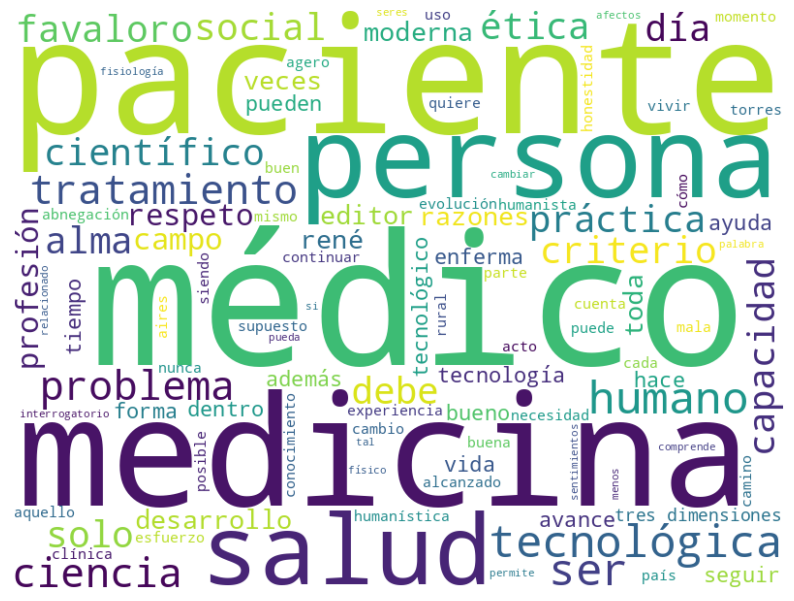

In [27]:
import string
import re
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
import matplotlib.pyplot as plt


stop_words_es = set(stopwords.words('spanish')) #stopwords en español


def limpiar_texto(texto):
    texto = texto.lower()
    texto = re.sub(r'\s+', ' ', texto)                      # Espacios vacios
    texto = re.sub(r'[^a-záéíóúñ\s]', '', texto)             # Caracteres extraños
    texto = re.sub(r'\d+', ' ', texto)                       # Números

    palabras = texto.split()
    palabras_filtradas = [p for p in palabras if p not in stop_words_es]
    return palabras_filtradas




palabras_originales = texto.lower().split() #palabras originales
cantidad_inicial = len(palabras_originales)


palabras_filtradas = limpiar_texto(texto)
cantidad_final = len(palabras_filtradas)

palabras_eliminadas = cantidad_inicial - cantidad_final #calcular las palabras eliminas

print(f"Cantidad inicial de palabras: {cantidad_inicial}")
print(f"Cantidad de palabras después de filtrar: {cantidad_final}")
print(f"¡Se eliminaron {palabras_eliminadas} palabras (stop-words y símbolos)!")


texto_final = ' '.join(palabras_filtradas) #unir palabras para el texto final


nube = WordCloud(
    width=800,
    height=600,
    background_color='white',
    colormap='viridis',
    max_words=100
).generate(texto_final)


plt.figure(figsize=(10, 8))
plt.imshow(nube, interpolation='bilinear')
plt.axis('off')
plt.show()

### 2.3 Usando el texto que conseguiste en el punto 1).



#### 2.3.1 Limpia y preprocesa el texto, descomponelo en oraciones, arma una matriz documento-vocabulario.


In [52]:
import string
import re



def quitar_emojis(texto):
    return re.sub(r'[^\w\s,]', '', texto)



def limpiar_texto(texto):
    texto = texto.lower()
    texto = quitar_emojis(texto)
    texto = re.sub(r'\d+', ' ', texto)
    palabras = texto.split()
    palabras = [p for p in palabras if p not in stopwords_es]
    return ' '.join(palabras)

In [53]:
import nltk

nltk.download('punkt', quiet=True)   #colocando esto nos ahorramos de que figure abajo que el recurso se descargo correctamente
nltk.download('punkt_tab', quiet=True)

oraciones = nltk.sent_tokenize(texto, language='spanish') #es el contador de oraciones

print("Cantidad de oraciones:", len(oraciones))

for oracion in oraciones[:5]:
    print(oracion)

Cantidad de oraciones: 87
«A veces nos preguntábamos cuáles eran las razones del éxito.
A mi entender todo se debía a la capacitación profesional y humanística que nos había dado la universidad y el Hospital Policlínico de La Plata, merced a la cual, podíamos dedicarnos con abnegación y amor a nuestra tarea de médicos a la que entregábamos todos nuestros esfuerzos.
Entendíamos ―porque lo llevábamos en el alma― que el acto médico debe estar rodeado de dignidad, caridad, igualdad, piedad, sacrificio, abnegación y renunciamiento.
Y por sobre todas las cosas habíamos procedido con honestidad […].
Estoy seguro, por otra parte, de que ese ha sido y sigue siendo el derrotero por donde transita la inmensa mayoría de los médicos rurales de mi país.


In [57]:
oraciones_limpias = []

for oracion in oraciones:
    oracion_limpia = limpiar_texto(oracion)
    oraciones_limpias.append(oracion_limpia)  #vamos agregando las oraciones limpias

print("Primeras 5 oraciones limpias:")

for oracion in oraciones_limpias[:5]:
    print(oracion)

Primeras 5 oraciones limpias:
veces preguntábamos cuáles razones éxito
entender debía capacitación profesional humanística dado universidad hospital policlínico plata, merced cual, podíamos dedicarnos abnegación amor tarea médicos entregábamos esfuerzos
entendíamos llevábamos alma acto médico debe rodeado dignidad, caridad, igualdad, piedad, sacrificio, abnegación renunciamiento
todas cosas procedido honestidad
seguro, parte, sido sigue siendo derrotero transita inmensa mayoría médicos rurales país


In [55]:
import numpy as np

documentos = np.char.split(oraciones_limpias)  #aca creamos los documentos que serian las oraciones limpias

documentos

array([list(['veces', 'preguntábamos', 'cuáles', 'razones', 'éxito']),
       list(['entender', 'debía', 'capacitación', 'profesional', 'humanística', 'dado', 'universidad', 'hospital', 'policlínico', 'plata', 'merced', 'podíamos', 'dedicarnos', 'abnegación', 'amor', 'tarea', 'médicos', 'entregábamos', 'esfuerzos']),
       list(['entendíamos', 'llevábamos', 'alma', 'acto', 'médico', 'debe', 'rodeado', 'dignidad', 'caridad', 'igualdad', 'piedad', 'sacrificio', 'abnegación', 'renunciamiento']),
       list(['todas', 'cosas', 'procedido', 'honestidad']),
       list(['seguro', 'parte', 'sido', 'sigue', 'siendo', 'derrotero', 'transita', 'inmensa', 'mayoría', 'médicos', 'rurales', 'país']),
       list(['buscábamos', 'obtener', 'sustento', 'económico', 'hacíamos', 'cobrando', 'justo', 'acuerdo', 'capacidad', 'cada', 'pacientes']),
       list(['toda', 'hora', 'esfuerzo', 'personal', 'capacidad', 'tecnológica', 'clínica', 'alcance', 'poniendo', 'práctica', 'aquello', 'salud', 'derecho', 'i

In [58]:
tokens = []

for doc in documentos:      #aca contamos en cada documento cuantos tokens(palabras)
    for word in doc:
        word_lower = word.lower()
        if word_lower not in tokens:
            tokens.append(word_lower)

print("Cantidad de palabras únicas:", len(tokens))


Cantidad de palabras únicas: 600


In [42]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

# Descartamos oraciones que quedaron vacías tras la limpieza
oraciones_validas = [o for o in oraciones_limpias if o.strip()]


cv = CountVectorizer()                        #iniciamos countvectorizer
X = cv.fit_transform(oraciones_validas)       # matriz dispersa con las frecuencias
vocabulario = cv.get_feature_names_out()      # lista de palabras únicas (ordenadas alfabéticamente)


nombres_docs = [f"Doc {i+1}" for i in range(X.shape[0])]  #creamos el dataframe para mejor visualización
df_cv = pd.DataFrame(X.toarray(), index=nombres_docs, columns=vocabulario)


print("Cantidad de documentos:", X.shape[0])
print("Cantidad de palabras del vocabulario:", len(vocabulario))
print("Tamaño de la matriz:", df_cv.shape)


df_cv.head(10)

Cantidad de documentos: 87
Cantidad de palabras del vocabulario: 599
Tamaño de la matriz: (87, 599)


,abarca,abnegación,abram,abrazo,absoluta,accidente,acompañada,acompañado,acompañe,acto,...,época,ética,éticos,éxito,íntegro,íntimamente,órganos,última,únicamente,único
Doc 1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
Doc 2,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Doc 3,0,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
Doc 4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Doc 5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Doc 6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Doc 7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Doc 8,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Doc 9,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Doc 10,0,0,0,0,0,0,0,0,1,0,...,0,1,0,0,0,0,0,0,0,0



#### 2.3.2 Determina la longitud de tu vocabulario.

In [43]:
print("Longitud del vocabulario:", len(vocabulario))

Longitud del vocabulario: 599



#### 2.3.3. Aplica TF-IDF a tu matriz documento-vocabulario

In [40]:

from sklearn.feature_extraction.text import TfidfTransformer

tfidf = TfidfTransformer()
X_tfidf = tfidf.fit_transform(X)

print("Tamaño de la matriz TF-IDF:", X_tfidf.shape)

Tamaño de la matriz TF-IDF: (87, 599)


In [41]:

top_palabras = df_cv.sum().sort_values(ascending=False).head(15).index

df_tfidf = pd.DataFrame(X_tfidf.toarray(), index=nombres_docs, columns=vocabulario).round(3)
df_tfidf[top_palabras].head(15)

,medicina,paciente,médico,persona,salud,ser,médicos,ciencia,tratamiento,alma,día,humano,criterio,favaloro,respeto
Doc 1,0.000,0.0,0.000,0.0,0.000,0.0,0.000,0.000,0.0,0.00,0.0,0.0,0.0,0.000,0.0
Doc 2,0.000,0.0,0.000,0.0,0.000,0.0,0.173,0.000,0.0,0.00,0.0,0.0,0.0,0.000,0.0
Doc 3,0.000,0.0,0.165,0.0,0.000,0.0,0.000,0.000,0.0,0.23,0.0,0.0,0.0,0.000,0.0
Doc 4,0.000,0.0,0.000,0.0,0.000,0.0,0.000,0.000,0.0,0.00,0.0,0.0,0.0,0.000,0.0
Doc 5,0.000,0.0,0.000,0.0,0.000,0.0,0.222,0.000,0.0,0.00,0.0,0.0,0.0,0.000,0.0
Doc 6,0.000,0.0,0.000,0.0,0.000,0.0,0.000,0.000,0.0,0.00,0.0,0.0,0.0,0.000,0.0
Doc 7,0.000,0.0,0.129,0.0,0.158,0.0,0.000,0.000,0.0,0.00,0.0,0.0,0.0,0.180,0.0
Doc 8,0.000,0.0,0.000,0.0,0.000,0.0,0.000,0.000,0.0,0.00,0.0,0.0,0.0,0.000,0.0
Doc 9,0.000,0.0,0.000,0.0,0.000,0.0,0.000,0.000,0.0,0.00,0.0,0.0,0.0,0.000,0.0
Doc 10,0.155,0.0,0.000,0.0,0.000,0.0,0.000,0.000,0.0,0.00,0.0,0.0,0.0,0.232,0.0


Explica el formato de tu matriz resultante: documentos, vocabulario, tamaño. Brinda tus conclusiones.

La matriz TF-IDF obtenida está formada por 87 documentos y 599 términos que conforman el vocabulario. En este caso, cada documento corresponde a una oración del texto analizado y cada columna representa una palabra diferente del vocabulario.

# Conclusiones
En este trabajo extraje una entrevista al reconocido Médico, René Favaloro, haciendo Scraping con la libreria BeautifulSoup, preprocesando el texto, pasandolo todo a minúscula, eliminando signos de puntuación y stopwords. Dividí el texto en oraciones, luego en tokens y realicé la matriz documento-vocabulario, donde finalmente a esa matriz le aplico TF-IDF.